# KernelGap Synthetic v4

The objective of this notebook will be the one of finding the best parameters for the synthetic dataset so that the classical kernel struggles while the quantum kernel performs well. 

For each optimizer:
- OPTUNA: Set of trials: 100, 500, 1000
    - OPTION 1: geometric difference
    - OPTION 2: haar distribution (TODO: modify first)
    - OPTION 4: KTA. 

- MEALPY: Set of generations: 30, 60, 100 & population size: 10, 20, 30
    - OPTION 1: geometric difference
    - OPTION 2: haar distribution (TODO: modify first, include MEALPY)
    - OPTION 4: KTA.

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
from config.config import *
from config.experiments import ExperimentConfig

import src.data.saving as saving
import src.utils.visuals as visuals

from src.data.preprocessing import preprocess_synthetic
from src.data.synthetic import KernelGap_synthetic_dataset
from src.data.saving import svm_exists, load_parameter_train, load_svm_results
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.classical_base import classical_baseline
from src.utils.visuals import *

from src.kernel.metrics import geometric_difference
from src.optimization.classical_base import classical_benchmark

## 1. Classical benchmarking

- Varying the numbers per class
- Varying the skip factor

In [10]:
skip_factors = np.linspace(2, 12, 11, dtype=int)
accuracies1, accuracies2, accuracies3 = [], [], []
for skip in skip_factors:
    accs1, accs2, accs3 = [], [], []
    for seed in range(5):  # a few seeds per skip factor
        X, y = KernelGap_synthetic_dataset(seed=seed, skipfactor=skip, n_per_class=20)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs1.append(results['accuracy'])

        X, y = KernelGap_synthetic_dataset(seed=seed, skipfactor=skip, n_per_class=40)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs2.append(results['accuracy'])

        X, y = KernelGap_synthetic_dataset(seed=seed, skipfactor=skip, n_per_class=100)
        X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)
        results = classical_benchmark(X_train, y_train, X_test, y_test)
        accs3.append(results['accuracy'])
    accuracies1.append(np.mean(accs1))
    accuracies2.append(np.mean(accs2))
    accuracies3.append(np.mean(accs3))

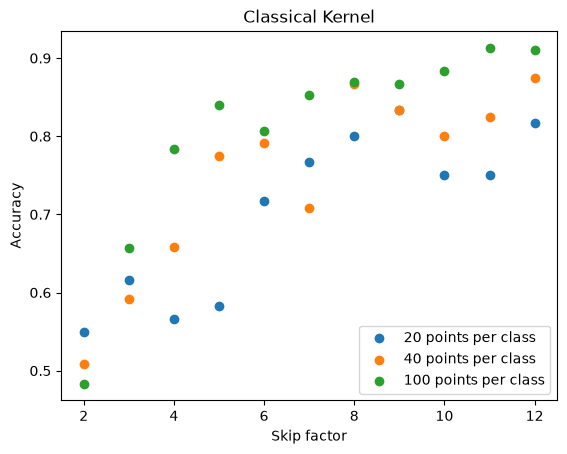

In [12]:
plt.scatter(skip_factors, accuracies1, label='20 points per class')
plt.scatter(skip_factors, accuracies2, label='40 points per class')
plt.scatter(skip_factors, accuracies3, label='100 points per class')
plt.ylabel('Accuracy')
plt.xlabel('Skip factor')
plt.title('Classical Kernel')
# plt.errorbar(skip_factors, accuracies1, yerr=np.std(accuracies1), fmt='o', label='20 points per class')
# plt.errorbar(skip_factors, accuracies2, yerr=np.std(accuracies2), fmt='o', label='40 points per class')
# plt.errorbar(skip_factors, accuracies3, yerr=np.std(accuracies3), fmt='o', label='100 points per class')
plt.legend()
plt.show()